In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gti-upm/leapgestrecog")

print("Path to dataset files:", path)

100%|██████████| 2.13G/2.13G [00:23<00:00, 99.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/gti-upm/leapgestrecog/versions/1


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

In [14]:
data_path = "/root/.cache/kagglehub/datasets/gti-upm/leapgestrecog/versions/1/leapGestRecog"

In [15]:
import os
import cv2
import numpy as np

IMG_SIZE = 28   # small = fast

def load_data(path, limit=3000):   # limit for speed
    X, y = [], []
    labels = []

    count = 0

    for subject in os.listdir(path):
        subject_path = os.path.join(path, subject)

        for gesture in os.listdir(subject_path):
            gesture_path = os.path.join(subject_path, gesture)

            if gesture not in labels:
                labels.append(gesture)

            label_index = labels.index(gesture)

            for img_name in os.listdir(gesture_path):
                if count >= limit:   # stop early for speed
                    return np.array(X), np.array(y), labels

                img_path = os.path.join(gesture_path, img_name)
                img = cv2.imread(img_path)

                if img is None:
                    continue

                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img / 255.0

                X.append(img)
                y.append(label_index)
                count += 1

    return np.array(X), np.array(y), labels


X, y, labels = load_data(data_path)

print("Shape:", X.shape)
print("Classes:", labels)

Shape: (3000, 28, 28, 3)
Classes: ['08_palm_moved', '03_fist', '07_ok', '09_c', '05_thumb', '04_fist_moved', '06_index', '02_l', '01_palm', '10_down']


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    Conv2D(16, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(64, activation='relu'),
    Dense(len(labels), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,002 (222.66 KB)

 Trainable params: 57,002 (222.66 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=3,          # fast
    batch_size=32
)

Epoch 1/3
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7271 - loss: 1.0050 - val_accuracy: 0.9917 - val_loss: 0.0690
Epoch 2/3
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9979 - loss: 0.0283 - val_accuracy: 0.9983 - val_loss: 0.0109
Epoch 3/3
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9996 - loss: 0.0072 - val_accuracy: 1.0000 - val_loss: 0.0039


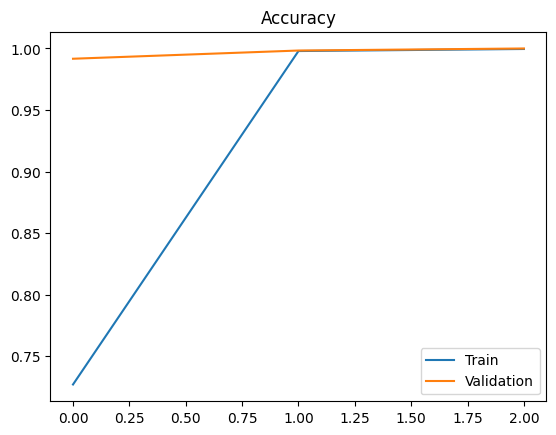

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00        80
           2       1.00      1.00      1.00        80
           3       1.00      1.00      1.00        80
           4       1.00      1.00      1.00        80
           5       1.00      1.00      1.00        40
           6       1.00      1.00      1.00        40
           7       1.00      1.00      1.00        40
           8       1.00      1.00      1.00        40
           9       1.00      1.00      1.00        40

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



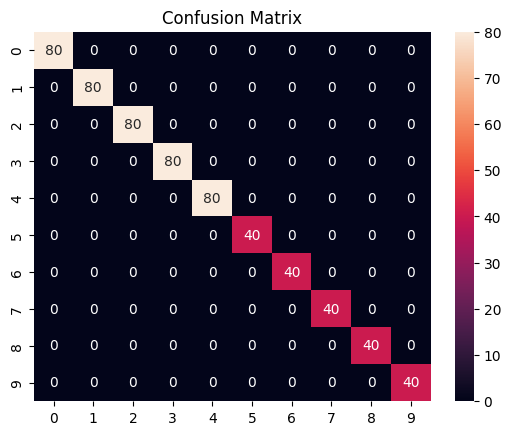

In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()